In [ ]:
import pickle
import pandas as pd

import os, sys
import numpy as np
import networkx as nx
import seaborn as sns
import scipy.stats as ss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from os.path import expanduser

from matplotlib.colors import LogNorm


sys.path.insert(1, os.path.join(sys.path[0], '..'))
import data_misc as dm
import model_misc as mm
import plot_misc as pm

import pandas as pd
from os.path import expanduser

# Phase Diagram S13

In [37]:
#fit/data properties to correlate
properties_x = [ ('gamma', r'\alpha_r') ]
properties_y = [ ('act_avg_rel', 't_r') ]

stat = 'KS' #chosen test statistic
alphamax = 1000 #maximum alpha for MLE fit
pval_thres = 0.1 #threshold above which alpha MLEs are considered
alph_thres = 1 #threshold below alphamax to define alpha MLE -> inf

#plotting variables
gridsize = 10 #grid size for hex bins: 40 

In [38]:
#locations
root_data = '../temporal_networks/' #root location of data/code
root_code = './'
saveloc = root_code+'files/data/' #location of output files


In [39]:
#dataset list: eventname, textname
datasets = [ #( 'MPC_Wu_SD01', 'Mobile (Wu 1)'),
                # ( 'MPC_Wu_SD02', 'Mobile (Wu 2)'),
                # ( 'MPC_Wu_SD03', 'Mobile (Wu 3)'),
                # ( 'Enron', 'Email (Enron)'),
                # ( 'email', 'Email (Kiel)'),
                # ( 'eml2', 'Email (Uni)'),
                ( 'email_Eu_core', 'Email (EU)'),
                # ( 'fb', 'Facebook'),
                # ( 'messages', 'Messages'),
                # ( 'pok', 'Dating'),
                # ( 'forum', 'Forum'),
                ( 'CollegeMsg', 'College'),
                ( 'CNS_calls', 'CNS (call)'),
                ( 'CNS_sms', 'CNS (sms)') ]

#sizes/widths/coords
plot_props = { 'xylabel' : 15,
'figlabel' : 26,
'ticklabel' : 15,
'text_size' : 15,
'marker_size' : 6,
'linewidth' : 2,
'tickwidth' : 1,
'barwidth' : 0.8,
'legend_prop' : { 'size':15 },
'legend_hlen' : 1,
'legend_np' : 1,
'legend_colsp' : 1.1 }

propx = gamma, propy = act_avg_rel
dataset name: email_Eu_core
dataset name: CollegeMsg
dataset name: CNS_calls
dataset name: CNS_sms


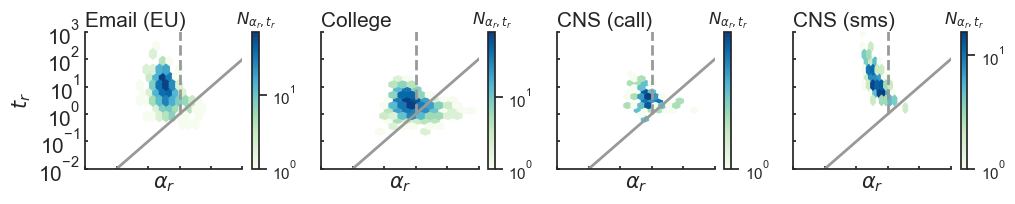

In [44]:
#loop through properties to correlate
for prop_pos, (propx, propy) in enumerate(zip( properties_x, properties_y )):
    print( 'propx = {}, propy = {}'.format( propx[0], propy[0] ) )

    #plot variables
    fig_props = { 'fig_num' : 1,
    'fig_size' : (10, 8),
    'aspect_ratio' : (4, 4),
    'grid_params' : dict( left=0.075, bottom=0.08, right=0.98, top=0.97, wspace=0.2, hspace=0.4 ),
    'dpi' : 300,
    'savename' : 'figure_fit_corrs' }

    #initialise plot
    sns.set( style='ticks' ) #set fancy fancy plot
    fig = plt.figure( fig_props['fig_num'], figsize=fig_props['fig_size'] )
    plt.clf()
    grid = gridspec.GridSpec( *fig_props['aspect_ratio'] )
    grid.update( **fig_props['grid_params'] )

    #loop through considered datasets
    for grid_pos, (eventname, textname) in enumerate(datasets):
        print( 'dataset name: ' + eventname ) #print output

        ## DATA ##

        #prepare ego network properties
        egonet_props = pd.read_pickle( saveloc + 'egonet_props_' + eventname + '.pkl' )
        #fit activity model to all ego networks in dataset
        egonet_fits = pd.read_pickle( saveloc + 'egonet_fits_' + eventname + '.pkl' )

        #filter egos according to fitting results
        egonet_filter, egonet_inf, egonet_null = dm.egonet_filter( egonet_props, egonet_fits, stat=stat, pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )

        #add relative quantities
        tau_rels = pd.Series( egonet_filter.strength - egonet_filter.degree * egonet_filter.act_min, name='str_rel' )
        t_rels = pd.Series( egonet_filter.act_avg - egonet_filter.act_min, name='act_avg_rel' )
        egonet_filter = pd.concat( [ egonet_filter, tau_rels, t_rels ], axis=1 )

        ## PLOTTING ##

        #initialise subplot
        ax = plt.subplot( grid[ grid_pos] )
        sns.despine( ax=ax ) #take out spines
        if grid_pos in [0, 1, 2, 3]:
            plt.xlabel( '$'+propx[1]+'$', size=plot_props['xylabel'] )
        if grid_pos in [0, 4, 8, 12]:
            plt.ylabel( '$'+propy[1]+'$', size=plot_props['xylabel'] )

        #plot plot!
        ## OLD
        # vmax = len(egonet_filter) #max value in colorbar (total number of egos in filtered dataset)
        # hexbin = plt.hexbin( propx[0], propy[0], data=egonet_filter, xscale='log', yscale='log', norm=LogNorm(vmin=1e0, vmax=vmax), mincnt=1, gridsize=gridsize, cmap='GnBu', zorder=0 )
        ## BEGIN NEW
        hexbin = plt.hexbin( propx[0], propy[0], data=egonet_filter, xscale='log', yscale='log', norm=LogNorm(vmin=1), mincnt=1, gridsize=gridsize, cmap='GnBu', zorder=0 )
        ## END NEW

        #colorbar
        cbar = plt.colorbar( hexbin, ax=ax )
        cbar.ax.set_title( r'$N_{'+propx[1]+','+propy[1]+'}$' )
        cbar.ax.minorticks_off()

        #lines
        if prop_pos == 0:
            plt.plot( [1e-4, 1e4], [1e-4, 1e4], '-', c='0.6', lw=plot_props['linewidth'], zorder=1 )
            plt.plot( [1, 1], [1, 1e4], '--', c='0.6', lw=plot_props['linewidth'], zorder=1 )

        #texts
        plt.text( 0, 1.15, textname, va='top', ha='left', transform=ax.transAxes, fontsize=plot_props['text_size'] )

        #finalise subplot
        if prop_pos == 0:
            plt.axis([ 1e-3, 1e2, 1e-2, 1e3 ])
        ax.tick_params( axis='both', which='both', direction='in', labelsize=plot_props['ticklabel'], length=2, pad=4 )
        ax.locator_params( numticks=5 )
        if grid_pos not in [12, 13, 14, 15]:
            ax.tick_params(labelbottom=False)
        if grid_pos not in [0, 4, 8, 12]:
            ax.tick_params(labelleft=False)

    #finalise plot
    if fig_props['savename'] != '':
        plt.savefig( fig_props['savename']+'.pdf', format='pdf', dpi=fig_props['dpi'] )


# Turnover correlations (S15)

In [61]:
#alpha fit variables
stat = 'KS' #chosen test statistic
alphamax = 1000 #maximum alpha for MLE fit
pval_thres = 0.1 #threshold above which alphas are considered
alph_thres = 1 #threshold below alphamax to define alpha MLE -> inf

#plotting variables
gridsize = 10 #grid size for hex bin
bins = 31 #number of bins in histograms
range_beta_diff = (-35, 35) #ranges for data
range_jaccard = (0, 1)

In [62]:
#locations
root_data = '../temporal_networks/' #root location of data/code
root_code = './'
saveloc = root_code+'files/data/' #location of output files

In [97]:
#dataset list: eventname, textname
datasets = [ # ( 'MPC_Wu_SD01.evt', 'Mobile (Wu 1)'),
                # ( 'MPC_Wu_SD02.evt', 'Mobile (Wu 2)'),
                # ( 'MPC_Wu_SD03.evt', 'Mobile (Wu 3)'),
                # ( 'Enron.evt', 'Email (Enron)'),
                #( 'email.evt', 'Email (Kiel)'),
                #( 'eml2.evt', 'Email (Uni)'),
                ( 'email_Eu_core.evt', 'Email (EU)'),
                ( 'contact.evt', 'UC San Diego'),
                # ( 'fb.evt', 'Facebook'),
                #( 'messages.evt', 'Messages'),
                #( 'pok.evt', 'Dating'),
                #( 'forum.evt', 'Forum'),
                ( 'CollegeMsg.evt', 'College'),
                ( 'CNS_calls.evt', 'CNS (call)'),
                ( 'CNS_sms.evt', 'CNS (sms)') ]

#sizes/widths/coords
plot_props = { 'xylabel' : 15,
'figlabel' : 26,
'ticklabel' : 13,
'text_size' : 8,
'marker_size' : 6,
'linewidth' : 2,
'tickwidth' : 1,
'barwidth' : 0.8,
'legend_prop' : { 'size':15 },
'legend_hlen' : 1,
'legend_np' : 1,
'legend_colsp' : 1.1 }

#plot variables
fig_props = { 'fig_num' : 1,
'fig_size' : (10, 8),
'aspect_ratio' : (4, 4),
'grid_params' : dict( left=0.07, bottom=0.07, right=0.965, top=0.965, wspace=0.5, hspace=0.45 ),
'dpi' : 300,
'savename' : 'figure_persistence_turnover' }

colors = sns.color_palette( 'GnBu', n_colors=3 ) #colors to plot

dataset name: email_Eu_core.evt
	filtered N = 395
dataset name: contact.evt
	filtered N = 31
dataset name: CollegeMsg.evt
	filtered N = 489
dataset name: CNS_calls.evt
	filtered N = 22
dataset name: CNS_sms.evt
	filtered N = 74


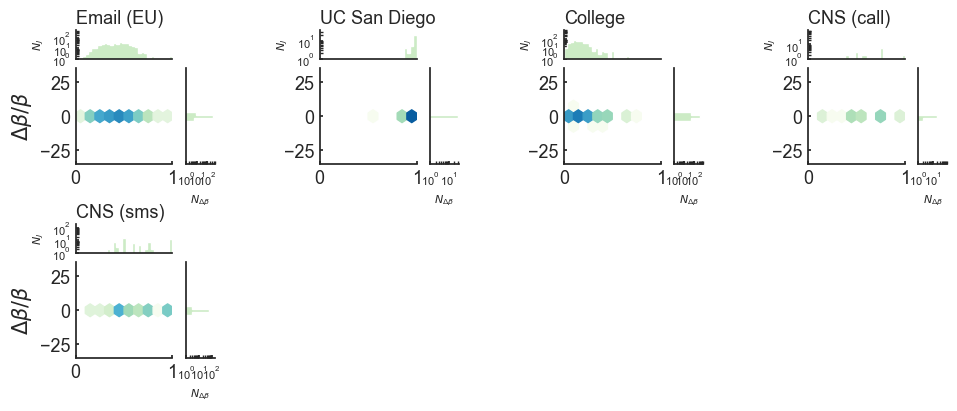

In [98]:
#initialise plot
sns.set( style='ticks' ) #set fancy fancy plot
fig = plt.figure( fig_props['fig_num'], figsize=fig_props['fig_size'] )
plt.clf()
grid = gridspec.GridSpec( *fig_props['aspect_ratio'] )
grid.update( **fig_props['grid_params'] )

#loop through considered datasets
for grid_pos, (eventname, textname) in enumerate(datasets):
    print( 'dataset name: ' + eventname ) #print output

    #initialise subplot
    plotgrid = grid[grid_pos].subgridspec( 2, 3, wspace=0.3, hspace=0.15, height_ratios=(0.3, 1), width_ratios=(1, 0.3,0.1) )

    ## DATA ##

    #load ego network properties / alter activities (all dataset and selected time periods)
    egonet_props = pd.read_pickle( saveloc + 'egonet_props_' + eventname[:-4] + '.pkl' )
    egonet_props_pieces = pd.read_pickle( saveloc + 'egonet_props_pieces_' + eventname[:-4] + '.pkl' )
    #compute Jaccard index of neighbor sets
    egonet_jaccard = dm.egonet_jaccard( eventname, 'y', saveloc )

    #fit activity model in all dataset and selected time periods
    egonet_fits = pd.read_pickle( saveloc + 'egonet_fits_' + eventname[:-4] + '.pkl' )
    egonet_fits_piece_0 = pd.read_pickle( saveloc + 'egonet_fits_piece_0_' + eventname[:-4] + '.pkl' )
    egonet_fits_piece_1 = pd.read_pickle( saveloc + 'egonet_fits_piece_1_' + eventname[:-4] + '.pkl' )

    #filter egos according to fitting results
    egonet_filt, egonet_inf, egonet_null = dm.egonet_filter( egonet_props, egonet_fits, stat=stat, pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )
    egonet_filt_piece_0, egonet_inf_piece_0, egonet_null_piece_0 = dm.egonet_filter( egonet_props_pieces[0], egonet_fits_piece_0, stat=stat, pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )
    egonet_filt_piece_1, egonet_inf_piece_1, egonet_null_piece_1 = dm.egonet_filter( egonet_props_pieces[1], egonet_fits_piece_1, stat=stat, pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )

    #get property for all egos common to both time periods
    props_filt = pd.concat( [ egonet_filt.beta ,
    egonet_filt_piece_0.beta.rename('beta_piece_0'),
    egonet_filt_piece_1.beta.rename('beta_piece_1')
    ], axis=1, join='inner' )

    ## PLOTTINMG ##

    plot_data = pd.concat( [
    ( ( props_filt.beta_piece_0 - props_filt.beta_piece_1 ) / props_filt.beta ).rename('beta_diff'),
    egonet_jaccard.rename('jaccard')
    ], axis=1, join='inner' )

    print('\tfiltered N = {}'.format(len(plot_data.index)))


    ## PLOTTING ##

    #main subplot: correlation between turnover (x) and persistence (y)

    #initialise subplot
    ax = plt.subplot( plotgrid[1,0] )
    sns.despine( ax=ax )
    if grid_pos in [12, 13, 14, 15]:
        plt.xlabel( '$J$', size=plot_props['xylabel'] )
    if grid_pos in [0, 4, 8, 12]:
        plt.ylabel( r'$\Delta \beta / \beta$', size=plot_props['xylabel'] )

    #plot plot!
    vmax = len(egonet_filt) #max value in colorbar (total number of egos in filtered dataset)
    hexbin = plt.hexbin( 'jaccard', 'beta_diff', data=plot_data, norm=LogNorm(vmin=1e0, vmax=vmax), mincnt=1, gridsize=gridsize, extent=[*range_jaccard, *range_beta_diff], cmap='GnBu' )

    #finalise plot
    plt.axis([ *range_jaccard, *range_beta_diff ])
    ax.tick_params( axis='both', which='both', direction='in', labelsize=plot_props['ticklabel'], length=2, pad=4 )

    #colorbar
    # ax=plt.subplot( plotgrid[1,2] ).set_axis_off()
    # cbar = plt.colorbar( hexbin, ax=ax, fraction=1 )
    # cbar.ax.set_title( r'$N_{J, \Delta \beta}$' )
    # cbar.ax.minorticks_off()

    #x marginal: turnover histogram

    #initialise subplot
    ax = plt.subplot( plotgrid[0,0] )
    sns.despine( ax=ax )
    plt.ylabel( r'$N_J$', size=plot_props['text_size'] )

    plt.text( 0, 1.1, textname, va='bottom', ha='left', transform=ax.transAxes, fontsize=plot_props['ticklabel'] )

    #plot plot!
    plt.hist( plot_data.jaccard, bins=bins, range=range_jaccard, log=True, histtype='stepfilled', color=colors[0] )

    #finalise subplot
    plt.axis([ *range_jaccard, 1e0, vmax ])
    ax.tick_params( axis='both', which='both', direction='in', labelsize=plot_props['text_size'], length=2, pad=4 )
    ax.locator_params( axis='y', numticks=2 )
    plt.xticks([])

    #y marginal: persistence histogram

    #initialise subplot
    ax = plt.subplot( plotgrid[1,1] )
    sns.despine( ax=ax )
    plt.xlabel( r'$N_{\Delta \beta}$', size=plot_props['text_size'] )

    #plot plot!
    plt.hist( plot_data.beta_diff, bins=bins, range=range_beta_diff, log=True, histtype='stepfilled', color=colors[0], orientation='horizontal' )

    #finalise subplot
    plt.axis([ 1e0, vmax, *range_beta_diff ])
    ax.tick_params( axis='both', which='both', direction='in', labelsize=plot_props['text_size'], length=2, pad=4 )
    ax.locator_params( axis='x', numticks=2 )
    plt.yticks([])

#finalise plot
if fig_props['savename'] != '':
    plt.savefig( fig_props['savename']+'.pdf', format='pdf', dpi=fig_props['dpi'] )


# Table statistics

In [99]:
root_loc = './' #root location of code
saveloc_data = './files/data/' #location of data files

#get parameters for all datasets (single and parallel)
params_data = pd.read_pickle( saveloc_data + 'params_data.pkl' )
# params_data_parallel = pd.read_pickle( saveloc_data + 'params_data_parallel.pkl' )


In [100]:
params_data

parameter,num_all,num_events,num_egos,avg_degree,avg_strength,avg_actavg,avg_actvar,avg_actmin,avg_actmax
dataset,,,,,,,,,
CNS_calls,525,3234,285,3.252632,18.996491,6.252877,122.266524,1.761404,12.470175
CNS_sms,568,24333,347,3.357349,114.734870,33.890743,14099.144883,5.657061,86.504323
Enron,86978,1134990,21984,22.520287,96.426674,3.260602,61.013206,1.150200,16.268377
email,57189,431864,9842,13.046434,65.682991,5.988001,5407.696788,1.786121,25.863239
eml2,3188,308730,2456,25.489821,250.099756,9.143629,2284.064595,1.117671,61.176710
fb,45813,854612,31429,11.043813,53.216329,4.082823,111.672079,1.165643,17.068217
forum,7084,1428493,4122,65.218341,691.150412,2.829741,449.917163,1.013100,57.407569
messages,35623,478015,20252,8.366186,45.135987,3.842397,1029.886553,1.233508,17.850928
pok,28972,430826,16239,13.046370,51.439005,3.442887,36.771167,1.112938,13.293368


In [101]:

## PRINTING ##

print(
r"""
\begin{table}[!ht]
\small
\noindent\makebox[\textwidth]{ \begin{tabular}{l l r r | r r r r r r}
\toprule
Dataset & Event & $N_u$ & $V$ & $N$ & $\langle k \rangle$ & $\langle \tau \rangle$ & $\langle t \rangle$ & $\langle a_0 \rangle$ & $\langle a_m \rangle$ \\
\midrule
# Mobile (call)~\cite{onnela2007analysis,onnela2007structure,karsai2011small,kivela2012multiscale,kovanen2013temporal,unicomb2018threshold,heydari2018multichannel} & Phone calls &"""
# +r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data_parallel.at[ 'call', 'num_all' ], params_data_parallel.at[ 'call', 'num_events' ], params_data_parallel.at[ 'call', 'num_egos' ], params_data_parallel.at[ 'call', 'avg_degree' ], params_data_parallel.at[ 'call', 'avg_strength' ], params_data_parallel.at[ 'call', 'avg_actavg' ], params_data_parallel.at[ 'call', 'avg_actmin' ], params_data_parallel.at[ 'call', 'avg_actmax' ] )+
# r"""
# Mobile (sms)~\cite{onnela2007analysis,onnela2007structure,karsai2011small,kivela2012multiscale,kovanen2013temporal,unicomb2018threshold,heydari2018multichannel} & Short messages &"""
# +r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data_parallel.at[ 'text', 'num_all' ], params_data_parallel.at[ 'text', 'num_events' ], params_data_parallel.at[ 'text', 'num_egos' ], params_data_parallel.at[ 'text', 'avg_degree' ], params_data_parallel.at[ 'text', 'avg_strength' ], params_data_parallel.at[ 'text', 'avg_actavg' ], params_data_parallel.at[ 'text', 'avg_actmin' ], params_data_parallel.at[ 'text', 'avg_actmax' ] )+
r"""
Mobile (Wu 1)~\cite{wu2010evidence} & Short messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'MPC_Wu_SD01', 'num_all' ], params_data.at[ 'MPC_Wu_SD01', 'num_events' ], params_data.at[ 'MPC_Wu_SD01', 'num_egos' ], params_data.at[ 'MPC_Wu_SD01', 'avg_degree' ], params_data.at[ 'MPC_Wu_SD01', 'avg_strength' ], params_data.at[ 'MPC_Wu_SD01', 'avg_actavg' ], params_data.at[ 'MPC_Wu_SD01', 'avg_actmin' ], params_data.at[ 'MPC_Wu_SD01', 'avg_actmax' ] )+
r"""
Mobile (Wu 2)~\cite{wu2010evidence} & Short messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'MPC_Wu_SD02', 'num_all' ], params_data.at[ 'MPC_Wu_SD02', 'num_events' ], params_data.at[ 'MPC_Wu_SD02', 'num_egos' ], params_data.at[ 'MPC_Wu_SD02', 'avg_degree' ], params_data.at[ 'MPC_Wu_SD02', 'avg_strength' ], params_data.at[ 'MPC_Wu_SD02', 'avg_actavg' ], params_data.at[ 'MPC_Wu_SD02', 'avg_actmin' ], params_data.at[ 'MPC_Wu_SD02', 'avg_actmax' ] )+
r"""
Mobile (Wu 3)~\cite{wu2010evidence} & Short messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'MPC_Wu_SD03', 'num_all' ], params_data.at[ 'MPC_Wu_SD03', 'num_events' ], params_data.at[ 'MPC_Wu_SD03', 'num_egos' ], params_data.at[ 'MPC_Wu_SD03', 'avg_degree' ], params_data.at[ 'MPC_Wu_SD03', 'avg_strength' ], params_data.at[ 'MPC_Wu_SD03', 'avg_actavg' ], params_data.at[ 'MPC_Wu_SD03', 'avg_actmin' ], params_data.at[ 'MPC_Wu_SD03', 'avg_actmax' ] )+
r"""
Email (Enron)~\cite{klimt2004enron,kunegis2013konect} & Emails &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'Enron', 'num_all' ], params_data.at[ 'Enron', 'num_events' ], params_data.at[ 'Enron', 'num_egos' ], params_data.at[ 'Enron', 'avg_degree' ], params_data.at[ 'Enron', 'avg_strength' ], params_data.at[ 'Enron', 'avg_actavg' ], params_data.at[ 'Enron', 'avg_actmin' ], params_data.at[ 'Enron', 'avg_actmax' ] )+
r"""
Email (Kiel)~\cite{ebel2002scale,saramaki2015exploring} & Emails &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'email', 'num_all' ], params_data.at[ 'email', 'num_events' ], params_data.at[ 'email', 'num_egos' ], params_data.at[ 'email', 'avg_degree' ], params_data.at[ 'email', 'avg_strength' ], params_data.at[ 'email', 'avg_actavg' ], params_data.at[ 'email', 'avg_actmin' ], params_data.at[ 'email', 'avg_actmax' ] )+
r"""
Email (Uni)~\cite{eckmann2004entropy,saramaki2015exploring} & Emails &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'eml2', 'num_all' ], params_data.at[ 'eml2', 'num_events' ], params_data.at[ 'eml2', 'num_egos' ], params_data.at[ 'eml2', 'avg_degree' ], params_data.at[ 'eml2', 'avg_strength' ], params_data.at[ 'eml2', 'avg_actavg' ], params_data.at[ 'eml2', 'avg_actmin' ], params_data.at[ 'eml2', 'avg_actmax' ] )+
r"""
Email (EU)~\cite{leskovec2007graph,paranjape2017motifs} & Emails &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'email_Eu_core', 'num_all' ], params_data.at[ 'email_Eu_core', 'num_events' ], params_data.at[ 'email_Eu_core', 'num_egos' ], params_data.at[ 'email_Eu_core', 'avg_degree' ], params_data.at[ 'email_Eu_core', 'avg_strength' ], params_data.at[ 'email_Eu_core', 'avg_actavg' ], params_data.at[ 'email_Eu_core', 'avg_actmin' ], params_data.at[ 'email_Eu_core', 'avg_actmax' ] )+
r"""
Facebook~\cite{viswanath2009evolution,saramaki2015exploring} & Online messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'fb', 'num_all' ], params_data.at[ 'fb', 'num_events' ], params_data.at[ 'fb', 'num_egos' ], params_data.at[ 'fb', 'avg_degree' ], params_data.at[ 'fb', 'avg_strength' ], params_data.at[ 'fb', 'avg_actavg' ], params_data.at[ 'fb', 'avg_actmin' ], params_data.at[ 'fb', 'avg_actmax' ] )+
r"""
Messages~\cite{said2010social,karimi2014structural,saramaki2015exploring} & Online messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'messages', 'num_all' ], params_data.at[ 'messages', 'num_events' ], params_data.at[ 'messages', 'num_egos' ], params_data.at[ 'messages', 'avg_degree' ], params_data.at[ 'messages', 'avg_strength' ], params_data.at[ 'messages', 'avg_actavg' ], params_data.at[ 'messages', 'avg_actmin' ], params_data.at[ 'messages', 'avg_actmax' ] )+
r"""
Dating~\cite{holme2004structure,saramaki2015exploring} & Online messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'pok', 'num_all' ], params_data.at[ 'pok', 'num_events' ], params_data.at[ 'pok', 'num_egos' ], params_data.at[ 'pok', 'avg_degree' ], params_data.at[ 'pok', 'avg_strength' ], params_data.at[ 'pok', 'avg_actavg' ], params_data.at[ 'pok', 'avg_actmin' ], params_data.at[ 'pok', 'avg_actmax' ] )+
r"""
Forum~\cite{said2010social,karimi2014structural,saramaki2015exploring} & Online messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'forum', 'num_all' ], params_data.at[ 'forum', 'num_events' ], params_data.at[ 'forum', 'num_egos' ], params_data.at[ 'forum', 'avg_degree' ], params_data.at[ 'forum', 'avg_strength' ], params_data.at[ 'forum', 'avg_actavg' ], params_data.at[ 'forum', 'avg_actmin' ], params_data.at[ 'forum', 'avg_actmax' ] )+
r"""
College~\cite{opsahl2009clustering,panzarasa2009patterns} & Online messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'CollegeMsg', 'num_all' ], params_data.at[ 'CollegeMsg', 'num_events' ], params_data.at[ 'CollegeMsg', 'num_egos' ], params_data.at[ 'CollegeMsg', 'avg_degree' ], params_data.at[ 'CollegeMsg', 'avg_strength' ], params_data.at[ 'CollegeMsg', 'avg_actavg' ], params_data.at[ 'CollegeMsg', 'avg_actmin' ], params_data.at[ 'CollegeMsg', 'avg_actmax' ] )+
r"""
CNS (call)~\cite{stopczynski2014measuring,sapiezynski2019interaction} & Phone calls &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'CNS_calls', 'num_all' ], params_data.at[ 'CNS_calls', 'num_events' ], params_data.at[ 'CNS_calls', 'num_egos' ], params_data.at[ 'CNS_calls', 'avg_degree' ], params_data.at[ 'CNS_calls', 'avg_strength' ], params_data.at[ 'CNS_calls', 'avg_actavg' ], params_data.at[ 'CNS_calls', 'avg_actmin' ], params_data.at[ 'CNS_calls', 'avg_actmax' ] )+
r"""
CNS (sms)~\cite{stopczynski2014measuring,sapiezynski2019interaction} & Short messages &"""
+r' {} & {} & {} & {:.2f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( params_data.at[ 'CNS_sms', 'num_all' ], params_data.at[ 'CNS_sms', 'num_events' ], params_data.at[ 'CNS_sms', 'num_egos' ], params_data.at[ 'CNS_sms', 'avg_degree' ], params_data.at[ 'CNS_sms', 'avg_strength' ], params_data.at[ 'CNS_sms', 'avg_actavg' ], params_data.at[ 'CNS_sms', 'avg_actmin' ], params_data.at[ 'CNS_sms', 'avg_actmax' ] )+
r"""
\bottomrule
\end{tabular}}
\caption{
\small {\bf Datasets used in this study}.
Characteristics of the available datasets, starting with system size $N_u$ (unfiltered number of egos) and number of events $V$ (all communication events between egos and alters). We only consider egos with mean alter activity larger than its minimum ($t > a_0$), leading to a system of size $N$ (filtered number of egos) with the following properties: average degree $\langle k \rangle$ (mean number of alters per ego), average strength $\langle \tau \rangle$ (mean number of events per ego), average mean alter activity $\langle t \rangle$ (mean number of events per alter per ego), and average minimum/maximum alter activity $\langle a_0 \rangle$ and $\langle a_m \rangle$ (mean of lowest/highest alter activity per ego). We include references to detailed studies of each dataset and locations of publicly available data.
}
\label{tab:datasets}
\end{table}
"""
)



\begin{table}[!ht]
\small
\noindent\makebox[\textwidth]{ \begin{tabular}{l l r r | r r r r r r}
\toprule
Dataset & Event & $N_u$ & $V$ & $N$ & $\langle k \rangle$ & $\langle \tau \rangle$ & $\langle t \rangle$ & $\langle a_0 \rangle$ & $\langle a_m \rangle$ \\
\midrule
# Mobile (call)~\cite{onnela2007analysis,onnela2007structure,karsai2011small,kivela2012multiscale,kovanen2013temporal,unicomb2018threshold,heydari2018multichannel} & Phone calls &
Mobile (Wu 1)~\cite{wu2010evidence} & Short messages & 44090 & 544817 & 16050 & 4.55 & 52.93 & 12.74 & 1.84 & 38.10 \\
Mobile (Wu 2)~\cite{wu2010evidence} & Short messages & 71042 & 636629 & 20534 & 4.71 & 43.86 & 10.66 & 1.91 & 29.86 \\
Mobile (Wu 3)~\cite{wu2010evidence} & Short messages & 14273 & 140611 & 4215 & 6.27 & 52.72 & 10.66 & 1.79 & 33.29 \\
Email (Enron)~\cite{klimt2004enron,kunegis2013konect} & Emails & 86978 & 1134990 & 21984 & 22.52 & 96.43 & 3.26 & 1.15 & 16.27 \\
Email (Kiel)~\cite{ebel2002scale,saramaki2015exploring} & Email

# Table model performance

In [81]:
#parameters
alphamax = 1000 #maximum alpha for MLE fit
pval_thres = 0.1 #threshold above which alpha MLEs are considered
alph_thres = 1 #threshold below alphamax to define alpha MLE -> inf

#locations
root_data = '../temporal_networks/' #root location of data/code
root_code = './'
saveloc = root_code+'files/data/' #location of output files

#dataset list: eventname, textname
datasets = [ 
                # ( 'MPC_Wu_SD01', 'Mobile (Wu 1)'),
                # ( 'MPC_Wu_SD02', 'Mobile (Wu 2)'),
                # ( 'MPC_Wu_SD03', 'Mobile (Wu 3)'),
                # ( 'Enron', 'Email (Enron)'),
                # ( 'email', 'Email (Kiel)'),
                # ( 'eml2', 'Email (Uni)'),
                ( 'email_Eu_core', 'Email (EU)'),
                # ( 'fb', 'Facebook'),
                # ( 'messages', 'Messages'),
                # ( 'pok', 'Dating'),
                # ( 'forum', 'Forum'),
                ( 'CollegeMsg', 'College'),
                ( 'CNS_calls', 'CNS (call)'),
                ( 'CNS_sms', 'CNS (sms)') ]


In [85]:
#initialise dataframe of filter properties
columns = [ 'num_egos', 'frac_egos_KS', 'frac_egos_W2', 'frac_egos_U2', 'frac_egos_A2' ]
params_stats = pd.DataFrame( np.zeros( ( len(datasets), len(columns) ) ), index=pd.Series( [ dset[0] for dset in datasets ], name='dataset') , columns=pd.Series( columns, name='parameter' ) )

#loop through considered datasets
for eventname, textname in datasets:
# for eventname, textname in datasets[2:]:
    print( 'dataset name: ' + eventname ) #print output

    #prepare ego network properties
    egonet_props = pd.read_pickle( saveloc + 'egonet_props_' + eventname + '.pkl' )
    #filter egos by t > a0 condition
    egonet_props_filter = egonet_props[ egonet_props.degree * egonet_props.act_min < egonet_props.strength ]
    #fit activity model to all ego networks in dataset
    egonet_fits = pd.read_pickle( saveloc + 'egonet_fits_' + eventname + '.pkl' )

    #filter egos according to fitting results
    #Kolmogorov-Smirnov
    egonet_filter_KS, not_used, not_used = dm.egonet_filter( egonet_props, egonet_fits, stat='KS', pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )
    #Cramer-von Mises
    egonet_filter_W2, not_used, not_used = dm.egonet_filter( egonet_props, egonet_fits, stat='W2', pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )
    egonet_filter_U2, not_used, not_used = dm.egonet_filter( egonet_props, egonet_fits, stat='U2', pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )
    egonet_filter_A2, not_used, not_used = dm.egonet_filter( egonet_props, egonet_fits, stat='A2', pval_thres=pval_thres, alphamax=alphamax, alph_thres=alph_thres )

    #fractions of statistically significant egos
    num_egos = len(egonet_props_filter) #all (filtered) egos!
    frac_egos_KS = len(egonet_filter_KS) / float(num_egos)
    frac_egos_W2 = len(egonet_filter_W2) / float(num_egos)
    frac_egos_U2 = len(egonet_filter_U2) / float(num_egos)
    frac_egos_A2 = len(egonet_filter_A2) / float(num_egos)

    #store in dframe
    params_stats.loc[ eventname ] = ( num_egos, frac_egos_KS, frac_egos_W2, frac_egos_U2, frac_egos_A2 )
    #fix dtypes
    params_stats.num_egos = params_stats.num_egos.astype(int)

dataset name: email_Eu_core
dataset name: CollegeMsg
dataset name: CNS_calls
dataset name: CNS_sms


In [86]:
## PRINTING ##

print(
r"""
\begin{table}[t]
\small
\noindent\makebox[\textwidth]{ \begin{tabular}{l r | r r r r}
\toprule
Dataset & $N$ & $n_{D}$ & $n_{W^2}$ & $n_{U^2}$ & $n_{A^2}$ \\
\midrule"""+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[0][1], *params_stats.loc[ 'call' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[1][1], *params_stats.loc[ 'text' ] )+'\n'
# +
# r'{} & - & - & - & - & - \\'.format( datasets[0][1], *params_stats.loc[ 'call' ] )+'\n'
# +
# r'{} & - & - & - & - & - \\'.format( datasets[1][1], *params_stats.loc[ 'text' ] )+'\n'
+
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[2][1], *params_stats.loc[ 'MPC_Wu_SD01' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[3][1], *params_stats.loc[ 'MPC_Wu_SD02' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[4][1], *params_stats.loc[ 'MPC_Wu_SD03' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[5][1], *params_stats.loc[ 'Enron' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[6][1], *params_stats.loc[ 'email' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[7][1], *params_stats.loc[ 'eml2' ] )+'\n'
# +
r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[8][1], *params_stats.loc[ 'email_Eu_core' ] )+'\n'
+
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[9][1], *params_stats.loc[ 'fb' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[10][1], *params_stats.loc[ 'messages' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[11][1], *params_stats.loc[ 'pok' ] )+'\n'
# +
# r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[12][1], *params_stats.loc[ 'forum' ] )+'\n'
# +
r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[13][1], *params_stats.loc[ 'CollegeMsg' ] )+'\n'
+
r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[14][1], *params_stats.loc[ 'CNS_calls' ] )+'\n'
+
r'{} & {:.0f} & {:.2f} & {:.2f} & {:.2f} & {:.2f} \\'.format( datasets[15][1], *params_stats.loc[ 'CNS_sms' ] )
+r"""
\bottomrule
\end{tabular}}
\caption{
\small {\bf Statistical significance of maximum likelihood estimation}. Fraction $n_{\bullet}$ of ego networks satisfying the condition $p_{\bullet} > 0.1$ on the $p$-value $p_{\bullet}$ associated to the test statistics of Kolmogorov-Smirnov, Cramér-von Mises, Watson, and Anderson-Darling [$\bullet = D, W^2, U^2, A^2$, respectively; see \esref{eq:KSstat}{eq:A2stat}]. Fractions $n_{\bullet}$ are calculated relative to the number $N$ of egos in each dataset under the condition $t > a_0$ (i.e. with any level of heterogeneity on their communication signatures). The model is able to reproduce observed data for most egos, at least according to some statistic. For large datasets, statistical significance is robust to the choice of statistic.
}
\label{tab:filterStats}
\end{table}
"""
)


IndexError: list index out of range